# Processo completo — foto → OCR → catálogo

Pipeline de ponta a ponta, **sem treinar**:

1. Lê as fotos em `data/images`.
2. **OBB** acha cada carta; **CROPPER** retifica 63×88 mm.
3. **OCR** lê nome, número e coleção (quando escrita).
4. Busca a carta **mais próxima** em `data/cards-data` (CSVs do Pokémon TCG).
5. Confere com a verdade em `data/card-images.csv`.

Rode as células em ordem. GPU ajuda no YOLO e no EasyOCR.


In [18]:
from __future__ import annotations

import re
import sys
import unicodedata
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from ultralytics import YOLO

REPO = Path(".").resolve()
if not (REPO / "CROPPER" / "rectify.py").exists():
    raise FileNotFoundError("Abra o notebook na raiz do repositório TCGTradeSegmentacao")

sys.path.insert(0, str(REPO / "CROPPER"))
sys.path.insert(0, str(REPO / "OCR"))

from crop_from_obb import DEFAULT_WEIGHTS, imgsz_for_weights
from rectify import crop_result
from read_card import read_card

DATA = REPO / "data"
IMAGES_DIR = DATA / "images"
CATALOG_DIR = DATA / "cards-data"
TRUTH_CSV = DATA / "card-images.csv"
OUT_DIR = DATA / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OBB_WEIGHTS = DEFAULT_WEIGHTS
OCR_WEIGHTS = REPO / "OCR" / "runs" / "ocr-roi-v1" / "weights" / "ocr-roi-v1.pt"
CARD_CONF = 0.8
OCR_CONF = 0.4
DEVICE = 0 if torch.cuda.is_available() else "cpu"

IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}


def fold(text: str) -> str:
    text = unicodedata.normalize("NFKD", text or "")
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    return re.sub(r"[^a-z0-9]+", "", text.lower())


def parse_number(text: str) -> tuple[int | None, int | None]:
    match = re.search(r"(\d+)\s*/\s*(\d+)", text or "")
    if match:
        return int(match.group(1)), int(match.group(2))
    digits = re.sub(r"\D", "", text or "")
    if len(digits) >= 3:
        return int(digits[:3]), int(digits[3:]) if len(digits) > 3 else None
    return None, None


def format_number(collector: int | None, total: int | None) -> str:
    if collector is None:
        return ""
    if total is None:
        return str(collector)
    return f"{collector}/{total}"


print("Repo     :", REPO)
print("Fotos    :", IMAGES_DIR, "exists=", IMAGES_DIR.is_dir())
print("Catálogo :", CATALOG_DIR, "exists=", CATALOG_DIR.is_dir())
print("Verdade  :", TRUTH_CSV, "exists=", TRUTH_CSV.is_file())
print("OBB      :", OBB_WEIGHTS, "exists=", OBB_WEIGHTS.is_file())
print("OCR ROI  :", OCR_WEIGHTS, "exists=", OCR_WEIGHTS.is_file())
print("Device   :", DEVICE)


Repo     : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao
Fotos    : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\data\images exists= True
Catálogo : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\data\cards-data exists= True
Verdade  : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\data\card-images.csv exists= True
OBB      : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\OBB\runs\obb\obb-v3\weights\obb-v3.pt exists= True
OCR ROI  : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\OCR\runs\ocr-roi-v1\weights\ocr-roi-v1.pt exists= True
Device   : 0


## 1. Catálogo (`data/cards-data`)

Cada CSV tem `Name`, `Number`, `Rarity`. O código da set (JTG, MEG, …) sai do nome do arquivo.


In [19]:
SET_CODE_BY_HINT = {
    "journey-together": "JTG",
    "destined-rivals": "DRI",
    "mega-evolution": "MEG",
    "ascended-heroes": "MEG",
    "phantasmal-flames": "MEG",
    "perfect-order": "MEG",
    "shrouded-fable": "SFA",
    "temporal-forces": "TEF",
    "paldean-fates": "PAF",
    "white-flare": "WHT",
    "black-bolt": "BLK",
    "obsidian-flames": "OBF",
    "paldea-evolved": "PAL",
    "scarlet-and-violet": "SVI",
    "paradox-rift": "PAR",
    "twilight-masquerade": "TWM",
    "stellar-crown": "SCR",
    "surging-sparks": "SSP",
    "prismatic-evolutions": "PRE",
    "astral-radiance": "ASR",
    "lost-origin": "LOR",
    "brilliant-stars": "BRS",
    "crown-zenith": "CRZ",
    "151": "MEW",
}


def set_code_from_path(path: Path) -> str:
    key = path.stem.lower().replace("pokemon-", "")
    for hint, code in SET_CODE_BY_HINT.items():
        if hint in key:
            return code
    letters = re.sub(r"[^a-z]", "", key)[:3].upper()
    return letters or path.stem[:3].upper()


def load_catalog(root: Path) -> pd.DataFrame:
    rows = []
    for csv_path in sorted(root.rglob("*.csv")):
        try:
            frame = pd.read_csv(csv_path)
        except Exception as exc:
            print("pulando", csv_path.name, exc)
            continue
        cols = {c.lower(): c for c in frame.columns}
        if "name" not in cols or "number" not in cols:
            continue
        series = csv_path.parent.name
        code = set_code_from_path(csv_path)
        for _, row in frame.iterrows():
            name = str(row[cols["name"]]).strip()
            number = str(row[cols["number"]]).strip()
            rarity = str(row[cols["rarity"]]).strip() if "rarity" in cols else ""
            collector, total = parse_number(number)
            rows.append(
                {
                    "name": name,
                    "number": number,
                    "rarity": rarity,
                    "set_code": code,
                    "set_file": csv_path.stem,
                    "series": series,
                    "collector": collector,
                    "total": total,
                    "name_fold": fold(name),
                }
            )
    catalog = pd.DataFrame(rows)
    catalog = catalog.drop_duplicates(subset=["name_fold", "number", "set_code"], keep="first")
    return catalog.reset_index(drop=True)


catalog = load_catalog(CATALOG_DIR)
print(f"{len(catalog):,} cartas em {catalog['set_file'].nunique()} arquivos")
print(catalog.sample(min(5, len(catalog)), random_state=0)[["name", "number", "set_code", "set_file"]])


20,182 cartas em 172 arquivos
               name     number set_code                           set_file
4857   Magma Energy      87/95      TEA    Pokemon-Team-Magma-vs-Team-Aqua
7575      Life Herb    108/127      PLA                   Pokemon-Platinum
3601       Whiscash     28/107      DEO                     Pokemon-Deoxys
18942        Litleo     19/106      FLA                  Pokemon-Flashfire
17186      Cinccino  SV094/122      SHI  Pokemon-Shining-Fates-Shiny-Vault


## 2. Verdade (`data/card-images.csv`)

Uma linha por carta visível na foto: arquivo, nome, número, coleção.


In [20]:
def load_truth(path: Path) -> pd.DataFrame:
    raw = pd.read_csv(path, header=None, names=["image", "name", "number", "collection"])
    raw["image"] = raw["image"].astype(str).str.strip()
    raw["name"] = raw["name"].fillna("").astype(str).str.strip()
    raw["number"] = raw["number"].fillna("").astype(str).str.strip()
    raw["collection"] = raw["collection"].fillna("").astype(str).str.strip()
    raw["collector"], raw["total"] = zip(*raw["number"].map(parse_number))
    return raw


truth = load_truth(TRUTH_CSV)
photos = sorted(
    p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in IMAGE_SUFFIXES
)
print(f"{len(photos)} foto(s)  |  {len(truth)} carta(s) anotadas")
display(truth)


5 foto(s)  |  21 carta(s) anotadas


,image,name,number,collection,collector,total
0,IMG_6689.jpg,Grimmsnarl,073/159,JTG,73,159
1,IMG_6689.jpg,Milcery,074/159,JTG,74,159
2,IMG_6689.jpg,Alcremie EX,075/159,JTG,75,159
3,IMG_6689.jpg,Cubone,076/159,JTG,76,159
4,IMG_6689.jpg,Swinub,077/159,JTG,77,159
5,IMG_6689.jpg,Piloswine,078/159,JTG,78,159
6,IMG_6689.jpg,Mamoswine EX,079/159,JTG,79,159
7,IMG_6689.jpg,Larvitar,080/159,JTG,80,159
8,IMG_6689.jpg,Pupitar,081/159,JTG,81,159
9,IMG_6697.jpg,Treino de Faixa Preta,145/159,JTG,145,159


## 3. Carta mais próxima no catálogo

Prioridade: **número** (collector + tamanho da set), depois **código da coleção**, depois **nome** (inglês no CSV × português no OCR).


In [21]:
from difflib import SequenceMatcher

_STOPWORDS = {
    "de", "da", "do", "dos", "das", "e", "o", "a", "os", "as",
    "the", "of", "and", "s", "lv",
}
_WORD_EN = {
    "castelo": "castle",
    "espirito": "spirit",
    "luta": "fighting",
    "busca": "scouting",
    "bolsa": "bag",
    "faixa": "band",
    "escolha": "choice",
    "treino": "training",
    "perola": "pearl",
    "lilian": "lillie",
    "lillian": "lillie",
    "lilies": "lillie",
    "lupo": "hop",
    "vastro": "vstar",
    "preta": "black",
    "hisui": "hisuian",
}


def folded_words(text: str) -> list[str]:
    text = (text or "").replace("'s", " ").replace("’s", " ").replace(".", " ")
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch)).lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    words: list[str] = []
    for word in text.split():
        match = re.match(r"^(.+?)(vstar|vastro|vmax|ex|gx)$", word)
        if match and len(match.group(1)) >= 3:
            words.extend([match.group(1), match.group(2)])
        else:
            words.append(word)
    return words


def name_tokens(text: str) -> set[str]:
    tokens = set()
    for word in folded_words(text):
        if word in _STOPWORDS or len(word) <= 1:
            continue
        tokens.add(_WORD_EN.get(word, word))
    return tokens


def names_equivalent(a: str, b: str) -> bool:
    """PT e EN contam como o mesmo nome (Castelo do N = N's Castle)."""
    if not str(a or "").strip() or not str(b or "").strip():
        return False
    if fold(a) == fold(b):
        return True
    left, right = name_tokens(a), name_tokens(b)
    if not left or not right:
        return SequenceMatcher(None, fold(a), fold(b)).ratio() >= 0.86
    inter = left & right
    if not inter:
        return SequenceMatcher(None, fold(a), fold(b)).ratio() >= 0.86
    if left <= right or right <= left:
        return True
    jacc = len(inter) / len(left | right)
    if jacc >= 0.5 and any(len(token) >= 4 for token in inter):
        return True
    return jacc >= 0.66 or SequenceMatcher(None, fold(a), fold(b)).ratio() >= 0.86


def name_score(ocr_name: str, cat_fold: str, cat_name: str) -> float:
    query = fold(ocr_name)
    if not query or not cat_fold:
        return 0.0
    if cat_name and names_equivalent(ocr_name, cat_name):
        return 1.0
    if query == cat_fold:
        return 1.0
    if query in cat_fold or cat_fold in query:
        return 0.88
    return SequenceMatcher(None, query, cat_fold).ratio()


def match_catalog(
    ocr_name: str,
    ocr_number: str,
    ocr_collection: str,
    catalog: pd.DataFrame,
    top_n: int = 3,
) -> pd.DataFrame:
    collector, total = parse_number(ocr_number)
    coll = re.sub(r"[^A-Za-z0-9]+", "", ocr_collection or "").upper()
    pool = catalog
    if collector is not None:
        near = catalog["collector"].notna() & (catalog["collector"] - collector).abs().le(2)
        subset = catalog.loc[near]
        if len(subset) >= 3:
            pool = subset
        if total is not None and len(subset):
            same_total = subset.loc[subset["total"] == total]
            if len(same_total):
                pool = same_total
    if coll:
        by_set = pool.loc[pool["set_code"] == coll]
        if len(by_set):
            pool = by_set
    if pool.empty:
        pool = catalog

    scored = pool.copy()
    scores = np.zeros(len(scored), dtype=np.float32)
    if collector is not None:
        same = scored["collector"] == collector
        scores = scores + np.where(same, 55.0, 0.0)
        near = scored["collector"].notna() & (scored["collector"] - collector).abs().le(2)
        scores = scores + np.where(near & ~same, 18.0, 0.0)
        if total is not None:
            scores = scores + np.where(scored["total"] == total, 35.0, 0.0)
    if coll:
        scores = scores + np.where(scored["set_code"] == coll, 18.0, 0.0)
    name_points = [
        28.0 * name_score(ocr_name, folded, cat_name)
        for folded, cat_name in zip(scored["name_fold"], scored["name"])
    ]
    scores = scores + np.asarray(name_points, dtype=np.float32)
    scored["score"] = scores
    out = scored.sort_values("score", ascending=False).head(top_n)
    return out.reset_index(drop=True)


# fumaça: Larvitar 080/159 JTG deve cair em Journey Together
demo = match_catalog("Larvitar", "080/159", "JTG", catalog, top_n=3)
display(demo[["name", "number", "set_code", "set_file", "rarity", "score"]])


,name,number,set_code,set_file,rarity,score
0,Larvitar,80/159,JTG,Pokemon-Journey-Together,Common,136.000000
1,Pupitar,81/159,JTG,Pokemon-Journey-Together,Common,85.933333
2,Regirock,82/159,JTG,Pokemon-Journey-Together,Rare,81.500000


## 4. Modelos

Detector de carta (OBB) + detector das faixas (OCR) + EasyOCR.


In [22]:
assert OBB_WEIGHTS.is_file(), f"Pesos OBB não encontrados: {OBB_WEIGHTS}"
assert OCR_WEIGHTS.is_file(), f"Pesos OCR não encontrados: {OCR_WEIGHTS}"
assert photos, f"Nenhuma imagem em {IMAGES_DIR}"

import easyocr

card_model = YOLO(str(OBB_WEIGHTS))
roi_model = YOLO(str(OCR_WEIGHTS))
reader = easyocr.Reader(["en", "pt"], gpu=torch.cuda.is_available())
OBB_IMGSZ = imgsz_for_weights(OBB_WEIGHTS)
print("OBB imgsz", OBB_IMGSZ, "| EasyOCR gpu", torch.cuda.is_available())


OBB imgsz 800 | EasyOCR gpu True


## 5. Extrair dados das fotos

Para cada imagem: detectar cartas → recortar → ler nome/número/coleção → top-3 do catálogo.


In [23]:
def sort_crops(crops, image_shape) -> list:
    h = max(int(image_shape[0]), 1)
    row_h = max(h / 4.0, 40.0)

    def key(card):
        cy = float(card.quad[:, 1].mean())
        cx = float(card.quad[:, 0].mean())
        return (int(cy / row_h), cx)

    return sorted(crops, key=key)


def card_to_bgr(card) -> np.ndarray:
    gray = card.image_bw
    if gray.ndim == 2:
        return cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    return gray


def extract_photo(path: Path) -> list[dict]:
    pred = card_model.predict(
        source=str(path),
        conf=CARD_CONF,
        imgsz=OBB_IMGSZ,
        device=DEVICE,
        verbose=False,
    )[0]
    crops = sort_crops(crop_result(pred, enhance=True, frame=False), pred.orig_img.shape)
    rows = []
    for card in crops:
        bgr = card_to_bgr(card)
        roi = roi_model.predict(
            source=bgr,
            conf=OCR_CONF,
            imgsz=800,
            device=DEVICE,
            verbose=False,
        )[0]
        read = read_card(roi, reader, image=bgr, conf_min=OCR_CONF)
        ranked = match_catalog(read.name, read.number, read.collection, catalog, top_n=3)
        best = ranked.iloc[0] if len(ranked) else None
        uid = f"{path.name}#{card.index}#{len(rows)}"
        rows.append(
            {
                "uid": uid,
                "image": path.name,
                "slot": card.index,
                "det_conf": round(card.conf, 3),
                "ocr_name": read.name,
                "ocr_number": read.number,
                "ocr_collection": read.collection,
                "match_name": "" if best is None else best["name"],
                "match_number": "" if best is None else best["number"],
                "match_set": "" if best is None else best["set_code"],
                "match_file": "" if best is None else best["set_file"],
                "match_rarity": "" if best is None else best["rarity"],
                "match_score": 0.0 if best is None else float(best["score"]),
                "crop_bgr": bgr,
                "quad": card.quad,
                "ranked": ranked,
                "regions": {
                    field: {
                        "quad": region.quad.copy(),
                        "source": region.source,
                        "text": region.text or getattr(read, field, ""),
                    }
                    for field, region in read.regions.items()
                },
            }
        )
    return rows


extracted: list[dict] = []
for photo in photos:
    part = extract_photo(photo)
    extracted.extend(part)
    print(f"{photo.name}: {len(part)} carta(s)")

extract_df = pd.DataFrame(
    [{k: v for k, v in row.items() if k not in {"crop_bgr", "quad", "ranked", "regions"}} for row in extracted]
)
extract_path = OUT_DIR / "pipeline_extract.csv"
extract_df.to_csv(extract_path, index=False, encoding="utf-8")
print("CSV:", extract_path)
display(extract_df)


IMG_6689.jpg: 9 carta(s)
IMG_6697.jpg: 9 carta(s)
WhatsApp Image 2026-08-19 at 00-35-13.jpg: 1 carta(s)
WhatsApp Image 2026-08-26 at 12-45-14.jpg: 1 carta(s)
WhatsApp Image 2026-08-26 at 13-22-29.jpg: 1 carta(s)
CSV: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\data\output\pipeline_extract.csv


,uid,image,slot,det_conf,ocr_name,ocr_number,ocr_collection,match_name,match_number,match_set,match_file,match_rarity,match_score
0,IMG_6689.jpg#3#0,IMG_6689.jpg,3,0.969,Grimmsn n,,,N,101/101,NOB,Pokemon-Noble-Victories,Rare Ultra,24.639999
1,IMG_6689.jpg#5#1,IMG_6689.jpg,5,0.966,Icer,,,Ice Rider Calyrex V,SWSH130/307,SWS,Pokemon-SWSH-Black-Star-Promos,Promo,24.639999
2,IMG_6689.jpg#8#2,IMG_6689.jpg,8,0.959,AlcremieCX,005/155,,Starmie,5/16,RUM,Pokemon-Rumble,nan,71.470589
3,IMG_6689.jpg#1#3,IMG_6689.jpg,1,0.971,Cubone,017/515,,Umbreon ★,17/17,POP,Pokemon-POP-Series-5,Rare,72.230770
4,IMG_6689.jpg#2#4,IMG_6689.jpg,2,0.969,Swinub,071/550,,Snubbull,71/95,CAL,Pokemon-Call-of-Legends,Common,71.000000
5,IMG_6689.jpg#0#5,IMG_6689.jpg,0,0.975,Pilos ine,576/454,,Piloswine,48/102,HST,Pokemon-HSTriumphant,Uncommon,28.000000
6,IMG_6689.jpg#4#6,IMG_6689.jpg,4,0.968,Mamoswinee,007/999,,Hitmonlee,7/62,FOS,Pokemon-Fossil,Rare Holo,69.736842
7,IMG_6689.jpg#7#7,IMG_6689.jpg,7,0.964,Larvitar,,,Larvitar,11/17,POP,Pokemon-POP-Series-1,Common,28.000000
8,IMG_6689.jpg#6#8,IMG_6689.jpg,6,0.966,Pupitar,,JGA,Pupitar,47/100,STO,Pokemon-Stormfront,Uncommon,28.000000
9,IMG_6697.jpg#3#0,IMG_6697.jpg,3,0.966,Treino de Faixa Preta,757/159,,Black Belt's Training,144/159,JTG,Pokemon-Journey-Together,Common,63.000000


## 6. Conferir com `card-images.csv`

Por foto, emparelha cada extração com uma linha da verdade (número primeiro, nome depois).

**Acerto** = é a mesma carta da planilha. Nome em **inglês no catálogo** vale como o nome em **português na foto** (`Castelo do N` = `N's Castle`). O número e/ou o código da set ainda precisam bater: Pupitar de outra coleção continua erro.


In [24]:
def numbers_equal(a: str, b: str) -> bool:
    ca, ta = parse_number(a)
    cb, tb = parse_number(b)
    if ca is None or cb is None:
        return False
    if ta is not None and tb is not None:
        return ca == cb and ta == tb
    return ca == cb


def sets_equal(a: str, b: str) -> bool:
    left = re.sub(r"[^A-Za-z0-9]+", "", a or "").upper()
    right = re.sub(r"[^A-Za-z0-9]+", "", b or "").upper()
    return bool(left) and left == right


def pair_ok(pred: dict, gt: pd.Series) -> bool:
    gt_name = str(gt.get("name", "") or "")
    gt_number = str(gt.get("number", "") or "")
    gt_set = str(gt.get("collection", "") or "")
    match_name = str(pred.get("match_name", "") or "")
    match_number = str(pred.get("match_number", "") or "")
    match_set = str(pred.get("match_set", "") or "")
    ocr_name = str(pred.get("ocr_name", "") or "")
    ocr_number = str(pred.get("ocr_number", "") or "")
    ocr_collection = str(pred.get("ocr_collection", "") or "")
    name_ok = names_equivalent(gt_name, match_name) or names_equivalent(gt_name, ocr_name)
    number_ok = numbers_equal(match_number, gt_number) or numbers_equal(ocr_number, gt_number)
    set_ok = sets_equal(gt_set, match_set) or sets_equal(gt_set, ocr_collection)
    if name_ok and number_ok:
        return True
    if number_ok and set_ok:
        return True
    if name_ok and set_ok:
        return True
    return False


def evaluate(extracted_rows: list[dict], truth_df: pd.DataFrame) -> pd.DataFrame:
    reports = []
    for image_name, group in truth_df.groupby("image"):
        preds = [row for row in extracted_rows if row["image"] == image_name]
        gts = group.reset_index(drop=True)
        used_pred: set[int] = set()
        used_gt: set[int] = set()
        candidates = []
        for gi, gt in gts.iterrows():
            for pi, pred in enumerate(preds):
                score = 0.0
                if numbers_equal(pred["match_number"], gt["number"]) or numbers_equal(
                    pred["ocr_number"], gt["number"]
                ):
                    score += 100
                if names_equivalent(pred["match_name"], gt["name"]) or names_equivalent(
                    pred["ocr_name"], gt["name"]
                ):
                    score += 80
                score += 40 * name_score(pred["match_name"], fold(gt["name"]), gt["name"])
                score += 20 * name_score(pred["ocr_name"], fold(gt["name"]), gt["name"])
                candidates.append((score, gi, pi))
        for _score, gi, pi in sorted(candidates, reverse=True):
            if gi in used_gt or pi in used_pred:
                continue
            gt = gts.loc[gi]
            ok = pair_ok(preds[pi], gt)
            used_gt.add(gi)
            used_pred.add(pi)
            reports.append(
                {
                    "image": image_name,
                    "gt_name": gt["name"],
                    "gt_number": gt["number"],
                    "gt_set": gt["collection"],
                    "ocr_name": preds[pi]["ocr_name"],
                    "ocr_number": preds[pi]["ocr_number"],
                    "ocr_collection": preds[pi]["ocr_collection"],
                    "match_name": preds[pi]["match_name"],
                    "match_number": preds[pi]["match_number"],
                    "match_set": preds[pi]["match_set"],
                    "match_score": preds[pi]["match_score"],
                    "ocr_ok": numbers_equal(preds[pi]["ocr_number"], gt["number"]),
                    "ok": ok,
                    "uid": preds[pi].get("uid", ""),
                }
            )
        for gi, gt in gts.iterrows():
            if gi in used_gt:
                continue
            reports.append(
                {
                    "image": image_name,
                    "gt_name": gt["name"],
                    "gt_number": gt["number"],
                    "gt_set": gt["collection"],
                    "ocr_name": "",
                    "ocr_number": "",
                    "ocr_collection": "",
                    "match_name": "",
                    "match_number": "",
                    "match_set": "",
                    "match_score": 0.0,
                    "ocr_ok": False,
                    "ok": False,
                    "uid": "",
                }
            )
        for pi, pred in enumerate(preds):
            if pi in used_pred:
                continue
            reports.append(
                {
                    "image": image_name,
                    "gt_name": "",
                    "gt_number": "",
                    "gt_set": "",
                    "ocr_name": pred["ocr_name"],
                    "ocr_number": pred["ocr_number"],
                    "ocr_collection": pred["ocr_collection"],
                    "match_name": pred["match_name"],
                    "match_number": pred["match_number"],
                    "match_set": pred["match_set"],
                    "match_score": pred["match_score"],
                    "ocr_ok": False,
                    "ok": False,
                    "uid": pred.get("uid", ""),
                }
            )
    return pd.DataFrame(reports)


eval_df = evaluate(extracted, truth)
eval_path = OUT_DIR / "pipeline_eval.csv"
eval_df.to_csv(eval_path, index=False, encoding="utf-8")

paired = eval_df[eval_df["gt_name"].astype(str).str.len() > 0]
n_ok = int(paired["ok"].sum())
n_gt = len(paired)
print(f"Acertos (carta do catálogo = número da verdade): {n_ok}/{n_gt}")
print("CSV:", eval_path)
display(eval_df)


Acertos (carta do catálogo = número da verdade): 12/21
CSV: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\data\output\pipeline_eval.csv


,image,gt_name,gt_number,gt_set,ocr_name,ocr_number,ocr_collection,match_name,match_number,match_set,match_score,ocr_ok,ok,uid
0,IMG_6689.jpg,Pupitar,081/159,JTG,Pupitar,,JGA,Pupitar,47/100,STO,28.000000,False,False,IMG_6689.jpg#6#8
1,IMG_6689.jpg,Larvitar,080/159,JTG,Larvitar,,,Larvitar,11/17,POP,28.000000,False,False,IMG_6689.jpg#7#7
2,IMG_6689.jpg,Piloswine,078/159,JTG,Pilos ine,576/454,,Piloswine,48/102,HST,28.000000,False,False,IMG_6689.jpg#0#5
3,IMG_6689.jpg,Cubone,076/159,JTG,Cubone,017/515,,Umbreon ★,17/17,POP,72.230770,False,False,IMG_6689.jpg#1#3
4,IMG_6689.jpg,Alcremie EX,075/159,JTG,AlcremieCX,005/155,,Starmie,5/16,RUM,71.470589,False,False,IMG_6689.jpg#8#2
5,IMG_6689.jpg,Swinub,077/159,JTG,Swinub,071/550,,Snubbull,71/95,CAL,71.000000,False,False,IMG_6689.jpg#2#4
6,IMG_6689.jpg,Mamoswine EX,079/159,JTG,Mamoswinee,007/999,,Hitmonlee,7/62,FOS,69.736842,False,False,IMG_6689.jpg#4#6
7,IMG_6689.jpg,Grimmsnarl,073/159,JTG,Grimmsn n,,,N,101/101,NOB,24.639999,False,False,IMG_6689.jpg#3#0
8,IMG_6689.jpg,Milcery,074/159,JTG,Icer,,,Ice Rider Calyrex V,SWSH130/307,SWS,24.639999,False,False,IMG_6689.jpg#5#1
9,IMG_6697.jpg,PP Up do N,153/159,JTG,PP do N Up,153/159,,N's PP Up,153/159,JTG,118.000000,True,True,IMG_6697.jpg#4#8


## 7. Gráfico de acertos e erros

Donut geral da **identificação no catálogo**, barras empilhadas por foto, e comparação com o OCR do número (a extração pode acertar o número e o match no CSV ainda escolher outra carta).


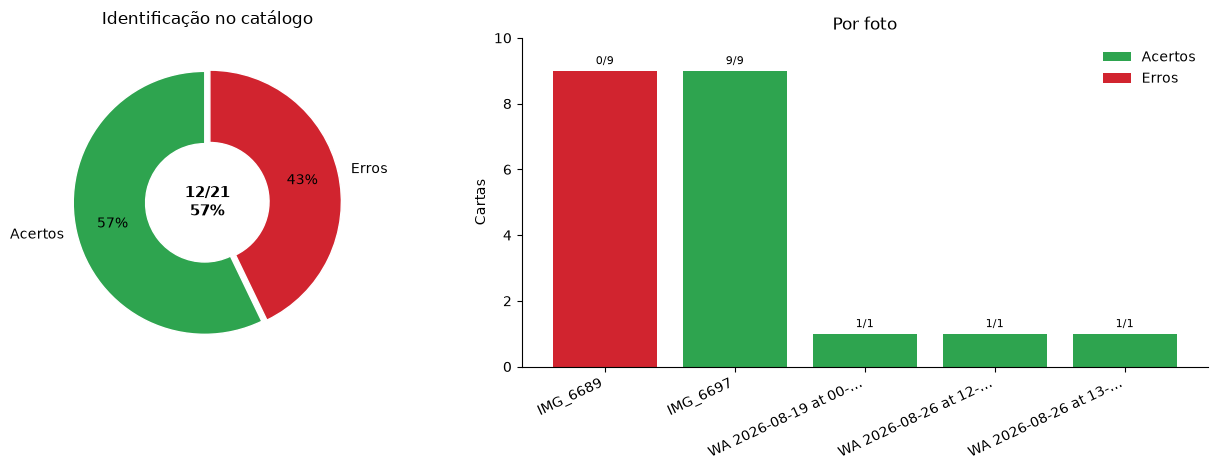

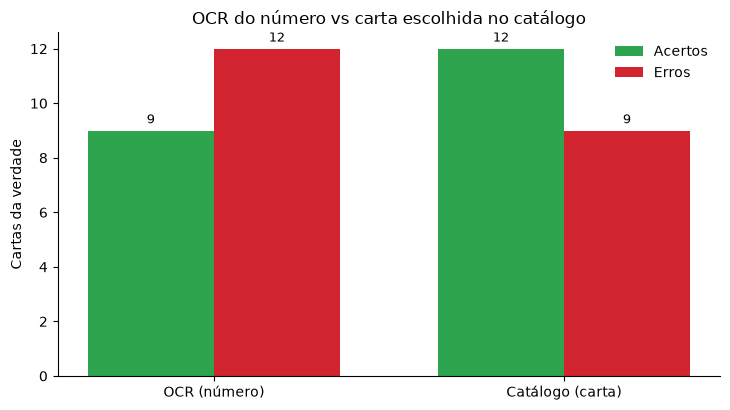

Identificação: 12 acertos, 9 erros
OCR número : 9 acertos, 12 erros
Figuras: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\data\output\pipeline_acertos.png
         C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\data\output\pipeline_acertos_etapas.png


In [25]:
gt_rows = eval_df[eval_df["gt_name"].astype(str).str.len() > 0].copy()
gt_rows["id_ok"] = [
    pair_ok(
        {
            "match_name": row["match_name"],
            "match_number": row["match_number"],
            "match_set": row["match_set"],
            "ocr_name": row["ocr_name"],
            "ocr_number": row["ocr_number"],
            "ocr_collection": row["ocr_collection"],
        },
        pd.Series(
            {
                "name": row["gt_name"],
                "number": row["gt_number"],
                "collection": row["gt_set"],
            }
        ),
    )
    for _, row in gt_rows.iterrows()
]
gt_rows["ocr_hit"] = [
    numbers_equal(str(a), str(b))
    for a, b in zip(gt_rows["ocr_number"], gt_rows["gt_number"])
]

if gt_rows.empty:
    print("Sem linhas da verdade para plotar.")
else:
    n_gt = len(gt_rows)
    n_id_ok = int(gt_rows["id_ok"].sum())
    n_id_err = n_gt - n_id_ok
    n_ocr_ok = int(gt_rows["ocr_hit"].sum())
    n_ocr_err = n_gt - n_ocr_ok

    def short_name(name: str) -> str:
        name = str(name).replace("WhatsApp Image ", "WA ").removesuffix(".jpg")
        return name if len(name) <= 22 else name[:20] + "…"

    per_img = (
        gt_rows.groupby("image", sort=False)
        .agg(acertos=("id_ok", "sum"), total=("id_ok", "size"))
        .reset_index()
    )
    per_img["erros"] = per_img["total"] - per_img["acertos"]
    per_img["label"] = per_img["image"].map(short_name)

    fig, axes = plt.subplots(
        1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1, 1.4]}
    )

    sizes = [n_id_ok, n_id_err] if (n_id_ok or n_id_err) else [1, 0]
    colors = ["#2ea44f", "#d1242f"]
    axes[0].pie(
        sizes,
        labels=["Acertos", "Erros"],
        colors=colors,
        autopct="%1.0f%%",
        startangle=90,
        explode=(0.02, 0.02),
        wedgeprops={"width": 0.55, "edgecolor": "white"},
        pctdistance=0.72,
    )
    axes[0].set_title("Identificação no catálogo", fontsize=12, pad=10)
    axes[0].text(
        0,
        0,
        f"{n_id_ok}/{n_gt}\n{100 * n_id_ok / n_gt:.0f}%",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
    )

    x = np.arange(len(per_img))
    axes[1].bar(x, per_img["acertos"], color="#2ea44f", label="Acertos")
    axes[1].bar(
        x, per_img["erros"], bottom=per_img["acertos"], color="#d1242f", label="Erros"
    )
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(per_img["label"], rotation=25, ha="right")
    axes[1].set_ylabel("Cartas")
    axes[1].set_title("Por foto")
    axes[1].legend(frameon=False, loc="upper right")
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)
    axes[1].set_ylim(0, int(per_img["total"].max()) + 1)
    for i, row in per_img.iterrows():
        axes[1].text(
            i,
            row["total"] + 0.12,
            f"{int(row['acertos'])}/{int(row['total'])}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    fig.tight_layout()
    fig_path = OUT_DIR / "pipeline_acertos.png"
    fig.savefig(fig_path, dpi=140, bbox_inches="tight")
    plt.show()

    fig2, ax = plt.subplots(figsize=(7.4, 4.2))
    labels = ["OCR (número)", "Catálogo (carta)"]
    acertos = [n_ocr_ok, n_id_ok]
    erros = [n_ocr_err, n_id_err]
    x = np.arange(len(labels))
    width = 0.36
    bars_ok = ax.bar(x - width / 2, acertos, width, color="#2ea44f", label="Acertos")
    bars_err = ax.bar(x + width / 2, erros, width, color="#d1242f", label="Erros")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Cartas da verdade")
    ax.set_title("OCR do número vs carta escolhida no catálogo")
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for bars in (bars_ok, bars_err):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(
                f"{int(height)}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
            )
    fig2.tight_layout()
    fig2_path = OUT_DIR / "pipeline_acertos_etapas.png"
    fig2.savefig(fig2_path, dpi=140, bbox_inches="tight")
    plt.show()

    print(f"Identificação: {n_id_ok} acertos, {n_id_err} erros")
    print(f"OCR número : {n_ocr_ok} acertos, {n_ocr_err} erros")
    print("Figuras:", fig_path)
    print("        ", fig2_path)


## 8. Só os erros — regiões, o que leu e o correto

Cartas em que o catálogo em inglês é o mesmo nome da foto em português **não entram aqui**. Em cada erro: faixas de nome (verde), número (azul) e coleção (amarelo), o texto do OCR e o valor da planilha.


9 erro(s) para revisar


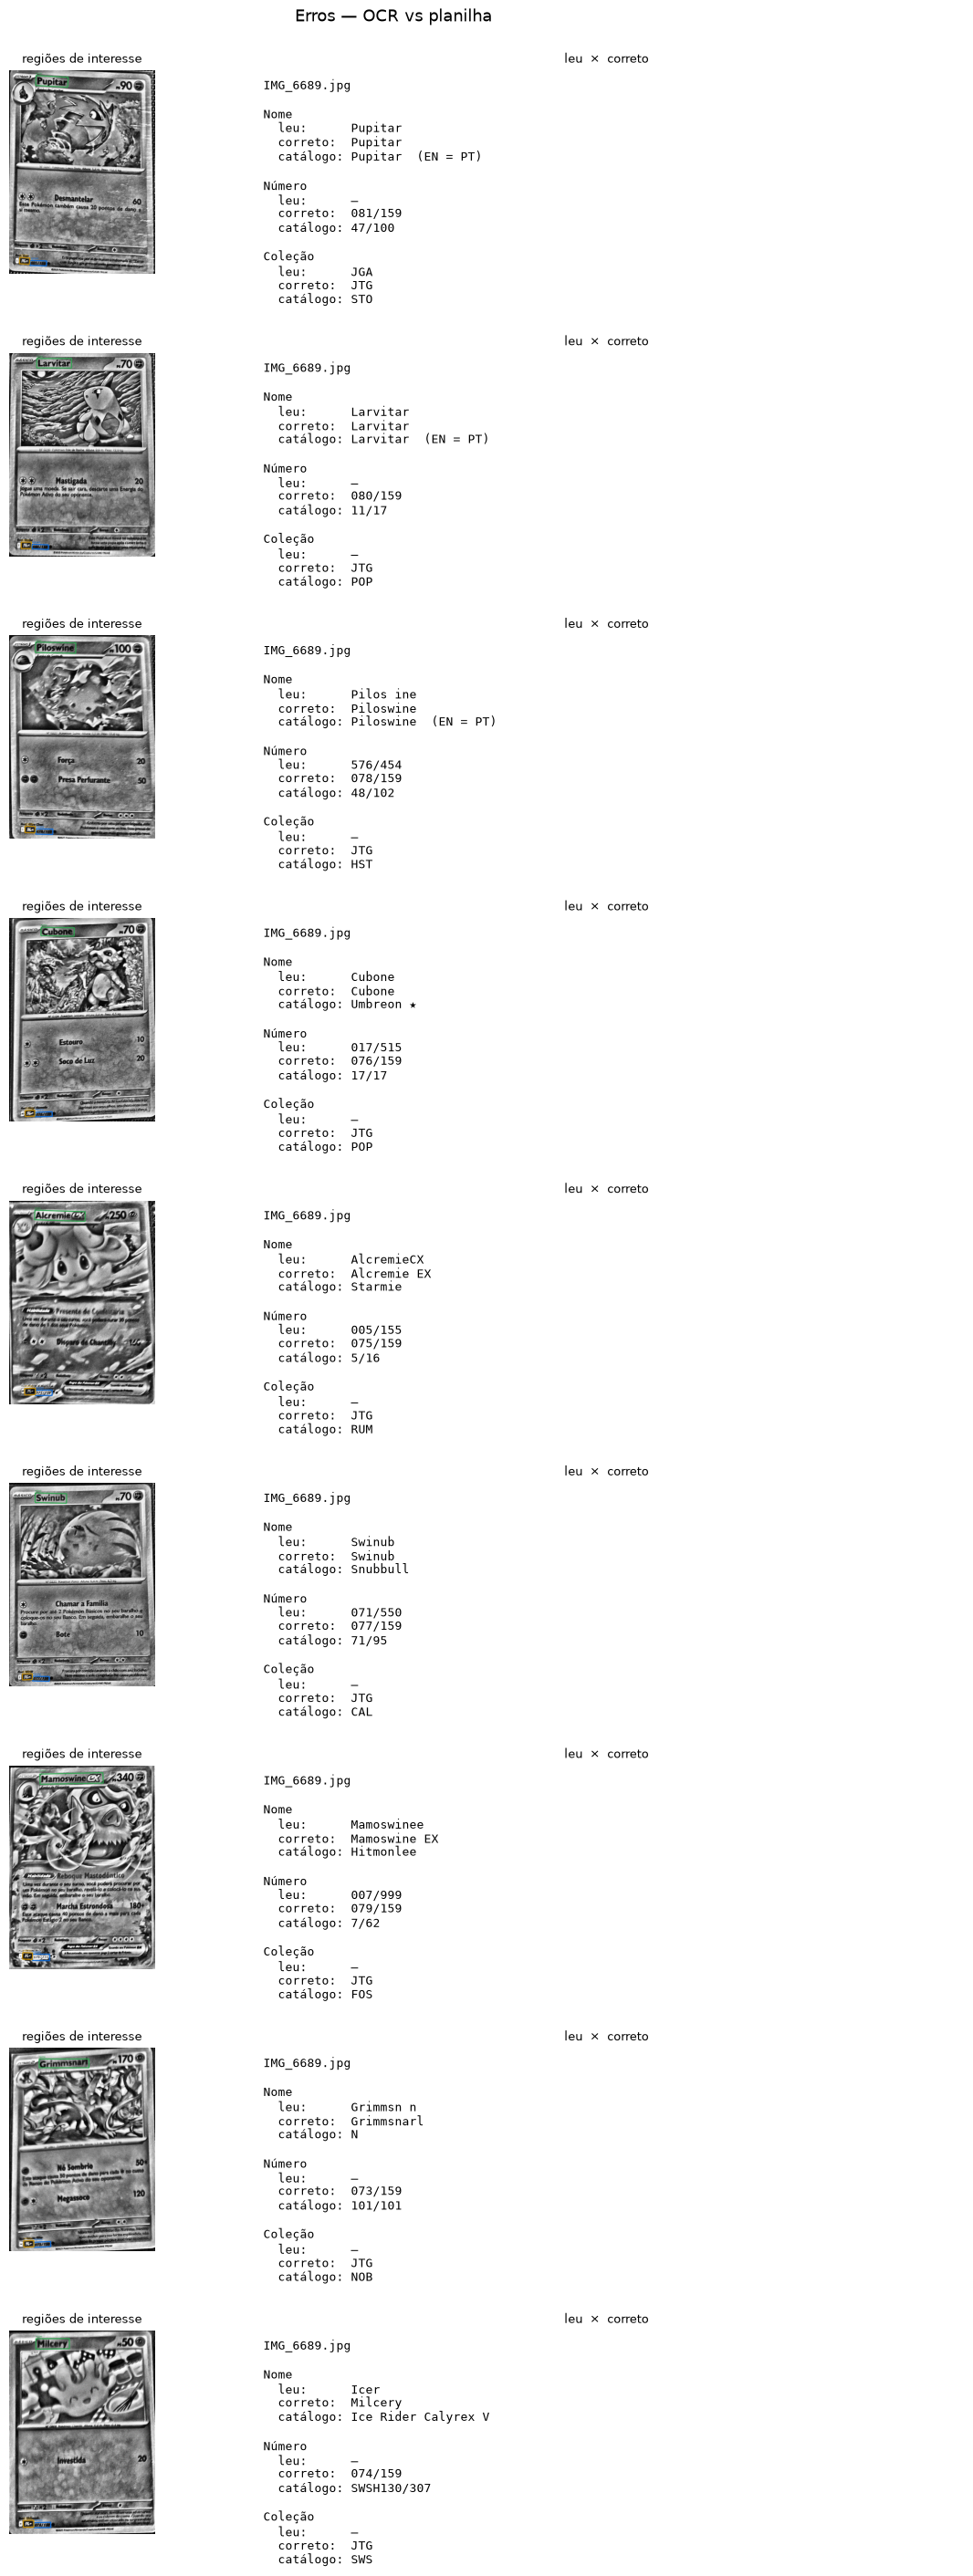

Figura: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\data\output\pipeline_erros.png


,image,gt_name,gt_number,gt_set,ocr_name,ocr_number,ocr_collection,match_name,match_number,match_set
0,IMG_6689.jpg,Pupitar,081/159,JTG,Pupitar,,JGA,Pupitar,47/100,STO
1,IMG_6689.jpg,Larvitar,080/159,JTG,Larvitar,,,Larvitar,11/17,POP
2,IMG_6689.jpg,Piloswine,078/159,JTG,Pilos ine,576/454,,Piloswine,48/102,HST
3,IMG_6689.jpg,Cubone,076/159,JTG,Cubone,017/515,,Umbreon ★,17/17,POP
4,IMG_6689.jpg,Alcremie EX,075/159,JTG,AlcremieCX,005/155,,Starmie,5/16,RUM
5,IMG_6689.jpg,Swinub,077/159,JTG,Swinub,071/550,,Snubbull,71/95,CAL
6,IMG_6689.jpg,Mamoswine EX,079/159,JTG,Mamoswinee,007/999,,Hitmonlee,7/62,FOS
7,IMG_6689.jpg,Grimmsnarl,073/159,JTG,Grimmsn n,,,N,101/101,NOB
8,IMG_6689.jpg,Milcery,074/159,JTG,Icer,,,Ice Rider Calyrex V,SWSH130/307,SWS


In [26]:
ROI_STYLE = {
    "name": {"color": (46, 164, 79), "label": "nome"},
    "number": {"color": (9, 105, 218), "label": "número"},
    "collection": {"color": (191, 135, 0), "label": "coleção"},
}


def annotate_regions(bgr: np.ndarray, regions: dict) -> np.ndarray:
    vis = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).copy() if bgr.ndim == 3 else cv2.cvtColor(bgr, cv2.COLOR_GRAY2RGB)
    h, w = vis.shape[:2]
    thick = max(2, int(round(min(h, w) / 220)))
    for field, info in (regions or {}).items():
        style = ROI_STYLE.get(field)
        if style is None:
            continue
        quad = np.asarray(info["quad"], dtype=np.int32).reshape(-1, 2)
        cv2.polylines(vis, [quad], True, style["color"], thick, cv2.LINE_AA)
        x, y = int(quad[:, 0].min()), int(quad[:, 1].min())
        cv2.putText(
            vis,
            style["label"],
            (max(2, x), max(16, y - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            style["color"],
            1,
            cv2.LINE_AA,
        )
    return vis


def find_extract(row) -> dict | None:
    uid = str(row.get("uid", "") or "")
    if uid:
        for item in extracted:
            if item.get("uid") == uid:
                return item
    cands = [
        item
        for item in extracted
        if item["image"] == row["image"]
        and item["ocr_name"] == row["ocr_name"]
        and item["ocr_number"] == row["ocr_number"]
    ]
    return cands[0] if cands else None


def blank(text: str) -> str:
    text = "" if pd.isna(text) else str(text).strip()
    return text if text else "—"


def field_lines(row) -> str:
    name_note = ""
    if names_equivalent(row["gt_name"], row["match_name"]):
        name_note = "  (EN = PT)"
    return (
        f"{row['image']}\n\n"
        f"Nome\n  leu:      {blank(row['ocr_name'])}\n"
        f"  correto:  {blank(row['gt_name'])}\n"
        f"  catálogo: {blank(row['match_name'])}{name_note}\n\n"
        f"Número\n  leu:      {blank(row['ocr_number'])}\n"
        f"  correto:  {blank(row['gt_number'])}\n"
        f"  catálogo: {blank(row['match_number'])}\n\n"
        f"Coleção\n  leu:      {blank(row['ocr_collection'])}\n"
        f"  correto:  {blank(row['gt_set'])}\n"
        f"  catálogo: {blank(row['match_set'])}"
    )


error_rows = gt_rows.loc[~gt_rows["id_ok"]].reset_index(drop=True) if "id_ok" in gt_rows.columns else pd.DataFrame()
if error_rows.empty:
    error_rows = eval_df[eval_df["gt_name"].astype(str).str.len() > 0].copy()
    error_rows = error_rows[
        [
            not pair_ok(
                {
                    "match_name": row["match_name"],
                    "match_number": row["match_number"],
                    "match_set": row["match_set"],
                    "ocr_name": row["ocr_name"],
                    "ocr_number": row["ocr_number"],
                    "ocr_collection": row["ocr_collection"],
                },
                pd.Series(
                    {
                        "name": row["gt_name"],
                        "number": row["gt_number"],
                        "collection": row["gt_set"],
                    }
                ),
            )
            for _, row in error_rows.iterrows()
        ]
    ].reset_index(drop=True)

n_err = len(error_rows)
print(f"{n_err} erro(s) para revisar")
if n_err == 0:
    print("Nenhum erro com o critério PT/EN.")
else:
    fig, axes = plt.subplots(
        n_err,
        2,
        figsize=(12.8, 3.15 * n_err),
        gridspec_kw={"width_ratios": [1.05, 1.45]},
    )
    axes = np.atleast_2d(axes)
    for i, row in error_rows.iterrows():
        ax_img, ax_txt = axes[i, 0], axes[i, 1]
        item = find_extract(row)
        if item is not None:
            vis = annotate_regions(item["crop_bgr"], item.get("regions") or {})
            ax_img.imshow(vis)
        else:
            ax_img.set_facecolor("#f0f0f0")
            ax_img.text(0.5, 0.5, "sem recorte", ha="center", va="center", transform=ax_img.transAxes)
        ax_img.set_title("regiões de interesse", fontsize=9)
        ax_img.axis("off")
        ax_txt.text(
            0.02,
            0.96,
            field_lines(row),
            transform=ax_txt.transAxes,
            va="top",
            ha="left",
            fontsize=9,
            family="monospace",
            linespacing=1.25,
        )
        ax_txt.set_title("leu  ×  correto", fontsize=9)
        ax_txt.axis("off")
    fig.suptitle("Erros — OCR vs planilha", fontsize=13, y=1.0)
    fig.tight_layout()
    err_path = OUT_DIR / "pipeline_erros.png"
    fig.savefig(err_path, dpi=130, bbox_inches="tight")
    plt.show()
    print("Figura:", err_path)
    display(error_rows[
        [
            "image",
            "gt_name",
            "gt_number",
            "gt_set",
            "ocr_name",
            "ocr_number",
            "ocr_collection",
            "match_name",
            "match_number",
            "match_set",
        ]
    ])


## 9. Galeria completa — recorte, OCR, match e se bateu com a planilha


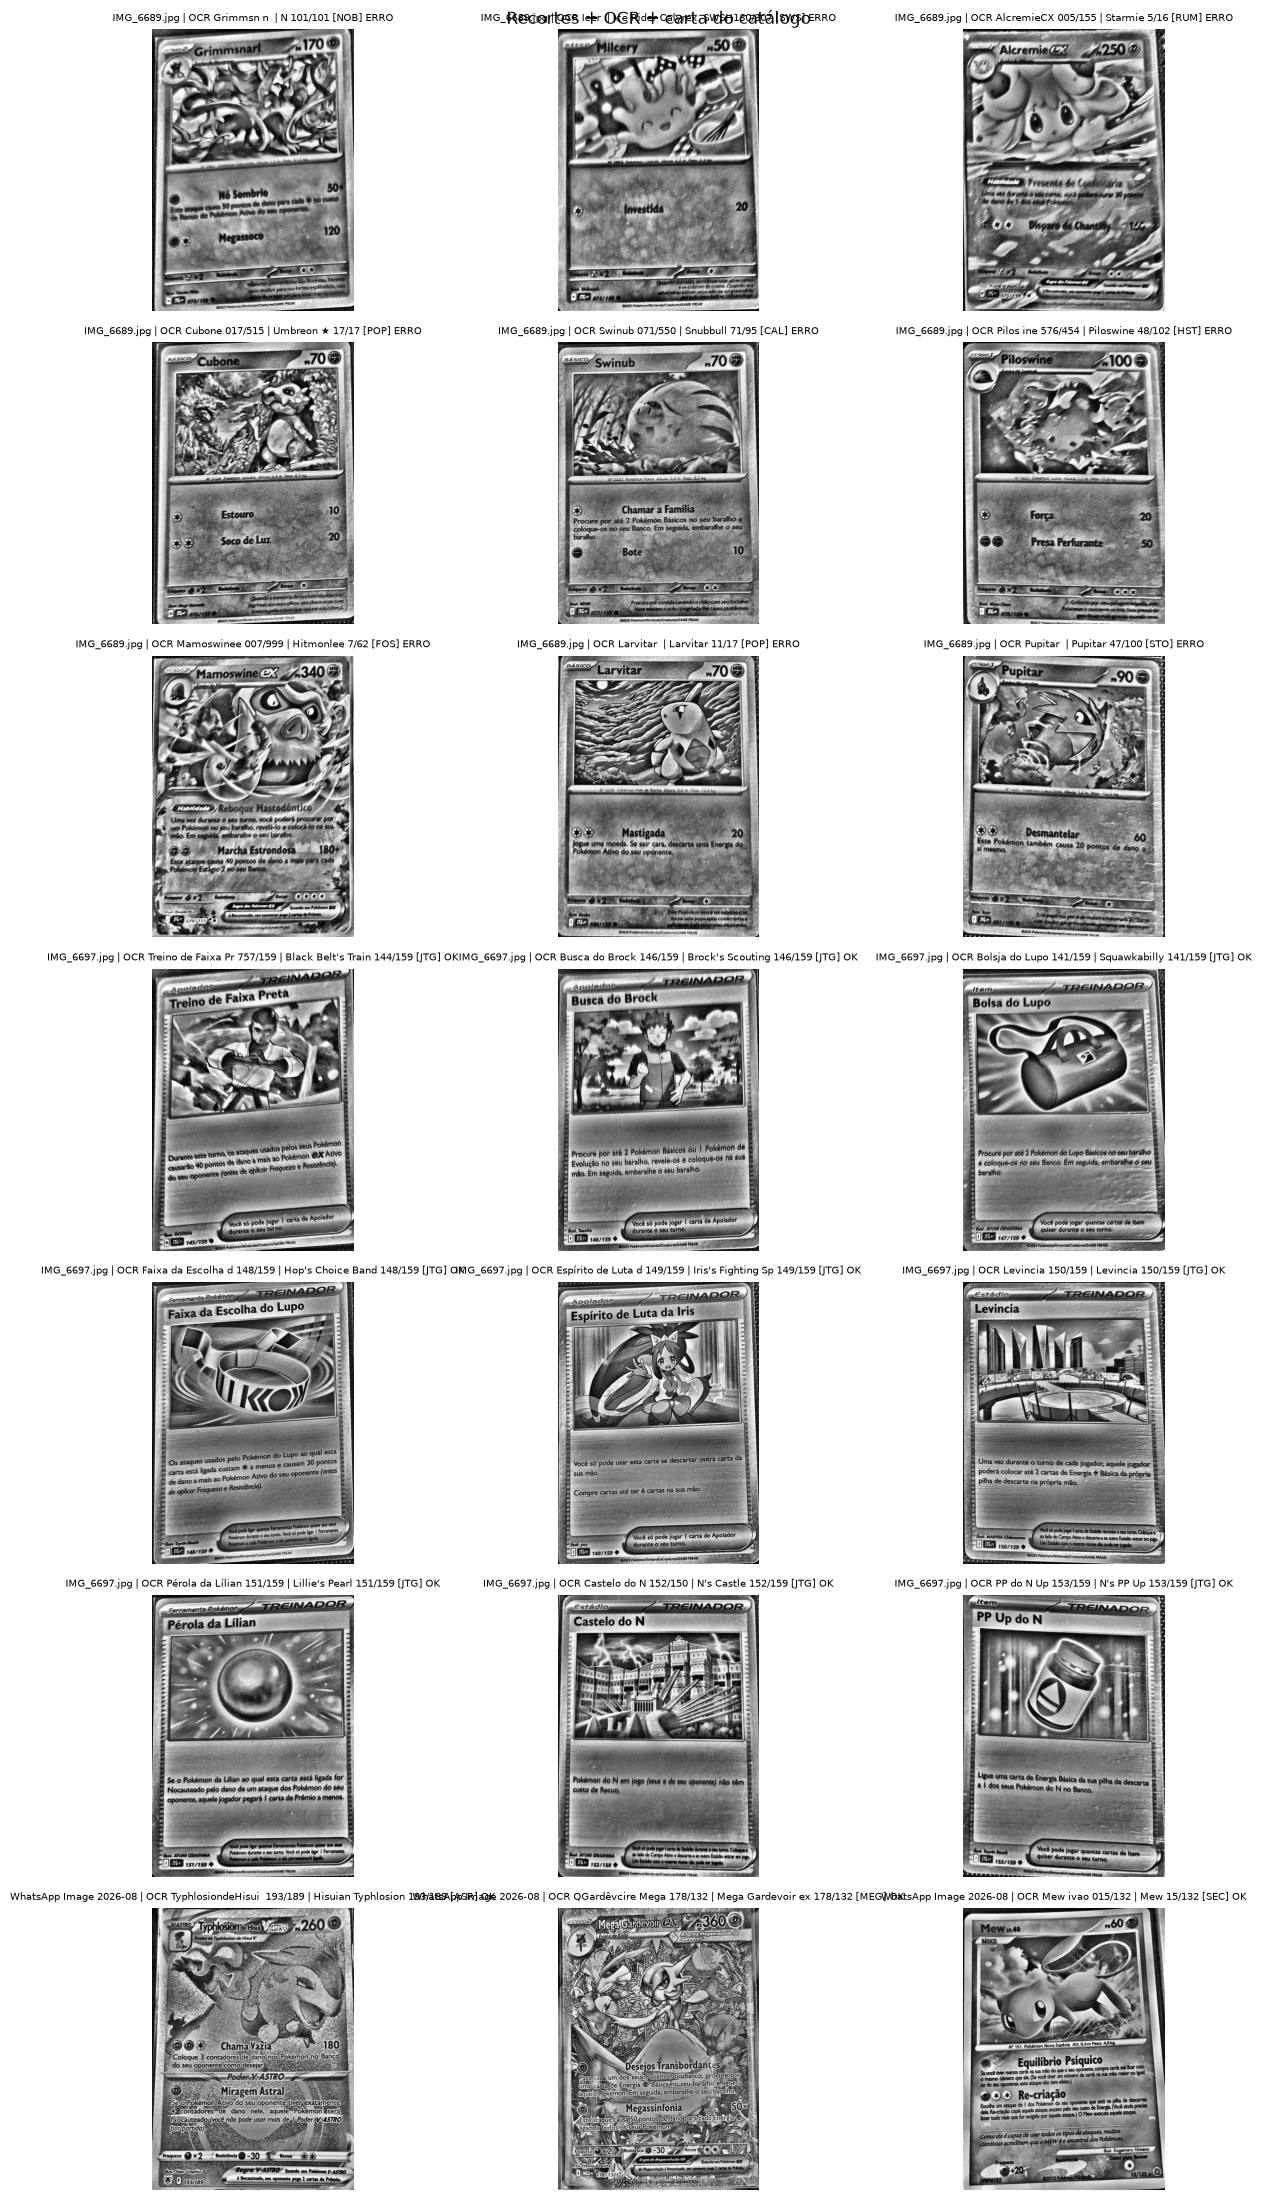

In [27]:
n = len(extracted)
if n == 0:
    print("Nenhuma carta extraída.")
else:
    cols = 3
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(14, 3.2 * rows))
    axes = np.atleast_2d(axes)
    lookup = eval_df.copy()
    for i, item in enumerate(extracted):
        ax = axes[i // cols, i % cols]
        vis = cv2.cvtColor(item["crop_bgr"], cv2.COLOR_BGR2RGB)
        ax.imshow(vis)
        hit = lookup[
            (lookup["image"] == item["image"])
            & (lookup["ocr_number"] == item["ocr_number"])
            & (lookup["ocr_name"] == item["ocr_name"])
        ]
        flag = ""
        if len(hit):
            r = hit.iloc[0]
            ok = pair_ok(
                {
                    "match_name": r["match_name"],
                    "match_number": r["match_number"],
                    "match_set": r["match_set"],
                    "ocr_name": r["ocr_name"],
                    "ocr_number": r["ocr_number"],
                    "ocr_collection": r["ocr_collection"],
                },
                pd.Series(
                    {
                        "name": r["gt_name"],
                        "number": r["gt_number"],
                        "collection": r["gt_set"],
                    }
                ),
            )
            flag = " OK" if ok else " ERRO"
        ax.set_title(
            f"{item['image'][:22]} | OCR {item['ocr_name'][:18]} {item['ocr_number']} "
            f"| {item['match_name'][:18]} {item['match_number']} [{item['match_set']}]{flag}",
            fontsize=7,
        )
        ax.axis("off")
    for j in range(n, rows * cols):
        axes[j // cols, j % cols].axis("off")
    fig.suptitle("Recortes + OCR + carta do catálogo")
    fig.tight_layout()
    plt.show()


Nome em inglês no catálogo (`N's Castle`, `Iris's Fighting Spirit`) conta como a carta em português. Se ainda aparecer erro: o OCR leu o número/coleção errados, ou o match pegou outra carta com o mesmo número em outra set.
